Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5906 - loss: 0.7548 - val_accuracy: 0.5772 - val_loss: 0.8265
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6334 - loss: 0.7237 - val_accuracy: 0.5691 - val_loss: 0.7969
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6375 - loss: 0.6996 - val_accuracy: 0.5854 - val_loss: 0.7721
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6558 - loss: 0.6786 - val_accuracy: 0.6098 - val_loss: 0.7522
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6599 - loss: 0.6600 - val_accuracy: 0.6098 - val_loss: 0.7318
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6599 - loss: 0.6433 - val_accuracy: 0.6098 - val_loss: 0.7142
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6640 - loss: 0.6278 - val_accuracy: 0.6098 - val_loss: 0.6967
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6640 - loss: 0.6131 - val_accuracy: 0.6179 - val_loss: 0.

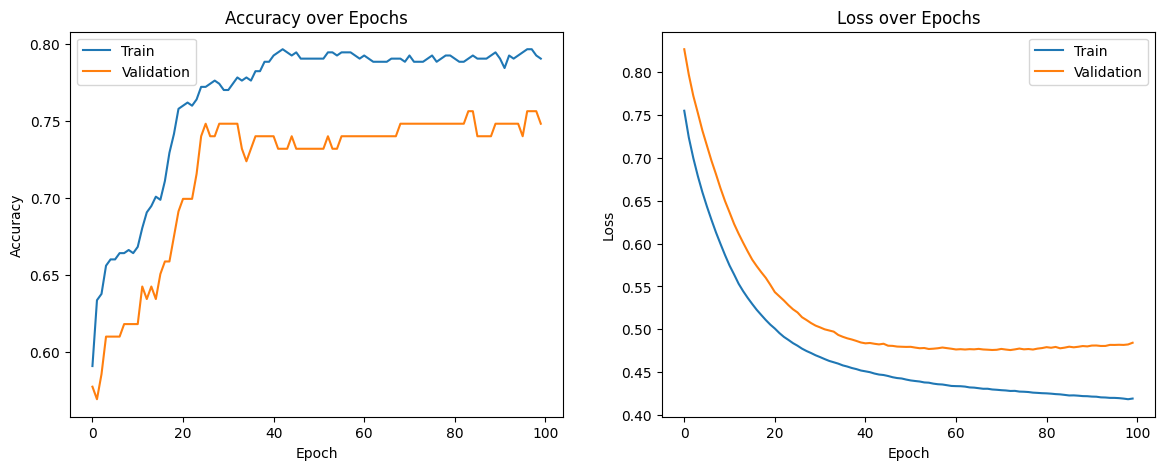

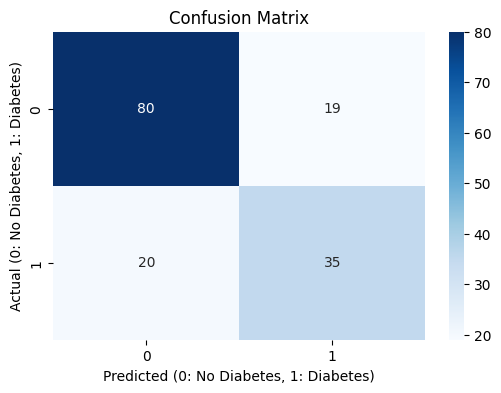

In [ ]:
# Install (runs only first time)
!pip install tensorflow pandas scikit-learn matplotlib seaborn -q

# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ==============================
# 2. Load Data
# ==============================
df = pd.read_csv('diabetes.csv')

# ==============================
# 3. Preprocessing
# ==============================
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# ==============================
# 4. Split Data
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 5. Feature Scaling
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# 6. Build ANN
# ==============================
model = Sequential([
    Dense(8, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(6, activation='relu'),
    Dense(1, activation='sigmoid')
])

# ==============================
# 7. Compile Model
# ==============================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==============================
# 8. Train Model
# ==============================
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=100,
    validation_split=0.2,
    verbose=1
)

# ==============================
# 9. Evaluate Model
# ==============================
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

print("\n--- RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==============================
# 10. Graphs
# ==============================
plt.figure(figsize=(14,5))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# ==============================
# 11. Confusion Matrix
# ==============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted (0: No Diabetes, 1: Diabetes)')
plt.ylabel('Actual (0: No Diabetes, 1: Diabetes)')

plt.show()